## 1. IMPORT DES BIBLIOTHÈQUES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. CHARGEMENT DU DATASET 

In [2]:
# 2. CHARGEMENT DU DATASET + RENOMMAGE EN FRANÇAIS
print("Chargement du dataset California Housing...")

# Chargement
housing = fetch_california_housing()

# Création du DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target * 100000

# RENOMMAGE DES COLONNES EN FRANÇAIS
df = df.rename(columns={
    'MedInc': 'Revenu_Median',
    'HouseAge': 'Age_Maisons',
    'AveRooms': 'Nb_Pieces_Moyen',
    'AveBedrns': 'Nb_Chambres_Moyen',
    'Population': 'Population',
    'AveOccup': 'Nb_Occupants_Moyen',
    'Latitude': 'Latitude',
    'Longitude': 'Longitude',
    'MedHouseVal': 'Prix'
})

print(f" Dataset chargé: {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f" Prix moyen: ${df['Prix'].mean():,.0f}")
print(f" Prix min: ${df['Prix'].min():,.0f}")
print(f" Prix max: ${df['Prix'].max():,.0f}")

print("\n Colonnes en français:")
print(df.columns.tolist())
print("\n Aperçu des données:")
df.head()

Chargement du dataset California Housing...
 Dataset chargé: 20640 lignes, 9 colonnes
 Prix moyen: $206,856
 Prix min: $14,999
 Prix max: $500,001

 Colonnes en français:
['Revenu_Median', 'Age_Maisons', 'Nb_Pieces_Moyen', 'AveBedrms', 'Population', 'Nb_Occupants_Moyen', 'Latitude', 'Longitude', 'Prix']

 Aperçu des données:


,Revenu_Median,Age_Maisons,Nb_Pieces_Moyen,AveBedrms,Population,Nb_Occupants_Moyen,Latitude,Longitude,Prix
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,342200.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Revenu_Median       20640 non-null  float64
 1   Age_Maisons         20640 non-null  float64
 2   Nb_Pieces_Moyen     20640 non-null  float64
 3   AveBedrms           20640 non-null  float64
 4   Population          20640 non-null  float64
 5   Nb_Occupants_Moyen  20640 non-null  float64
 6   Latitude            20640 non-null  float64
 7   Longitude           20640 non-null  float64
 8   Prix                20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## 3. STATISTIQUES DESCRIPTIVES


In [5]:
print(" Statistiques descriptives:")
df.describe()

 Statistiques descriptives:


,Revenu_Median,Age_Maisons,Nb_Pieces_Moyen,AveBedrms,Population,Nb_Occupants_Moyen,Latitude,Longitude,Prix
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,206855.816909
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,115395.615874
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,14999.000000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,119600.000000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,179700.000000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,264725.000000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,500001.000000


## 4. VÉRIFICATION DES VALEURS MANQUANTES

In [6]:
print(" Valeurs manquantes:")
print(df.isnull().sum())
print(f"\n Total valeurs manquantes: {df.isnull().sum().sum()}")

 Valeurs manquantes:
Revenu_Median         0
Age_Maisons           0
Nb_Pieces_Moyen       0
AveBedrms             0
Population            0
Nb_Occupants_Moyen    0
Latitude              0
Longitude             0
Prix                  0
dtype: int64

 Total valeurs manquantes: 0


## 5. VISUALISATION 1: DISTRIBUTION DES PRIX

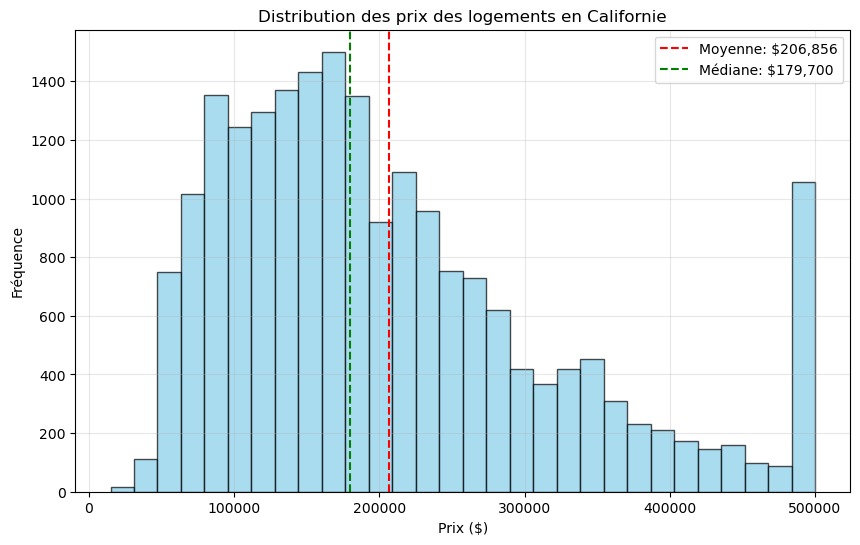

In [7]:
plt.figure(figsize=(10, 6))
plt.hist(df['Prix'], bins=30, edgecolor='black', color='skyblue', alpha=0.7)
plt.axvline(df['Prix'].mean(), color='red', linestyle='--', 
            label=f'Moyenne: ${df["Prix"].mean():,.0f}')
plt.axvline(df['Prix'].median(), color='green', linestyle='--', 
            label=f'Médiane: ${df["Prix"].median():,.0f}')
plt.xlabel('Prix ($)')
plt.ylabel('Fréquence')
plt.title('Distribution des prix des logements en Californie')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. VISUALISATION 2: PRIX VS REVENU MÉDIAN

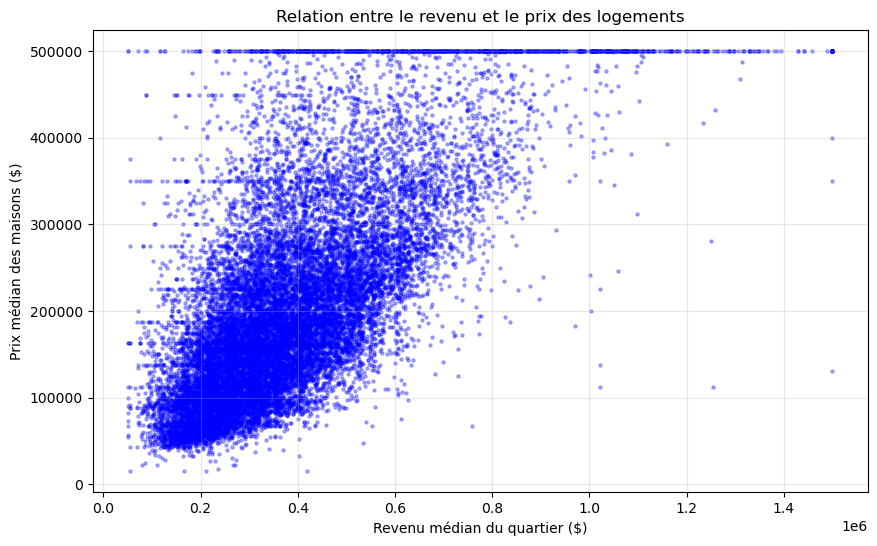

 Corrélation revenu-prix: 0.688


In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Revenu_Median']*100000, df['Prix'], alpha=0.3, s=5, c='blue')
plt.xlabel('Revenu médian du quartier ($)')
plt.ylabel('Prix médian des maisons ($)')
plt.title('Relation entre le revenu et le prix des logements')
plt.grid(True, alpha=0.3)
plt.show()

# Calcul de la corrélation
correlation = df['Revenu_Median'].corr(df['Prix']/100000)
print(f" Corrélation revenu-prix: {correlation:.3f}")

## 7. VISUALISATION 3: MATRICE DE CORRÉLATION

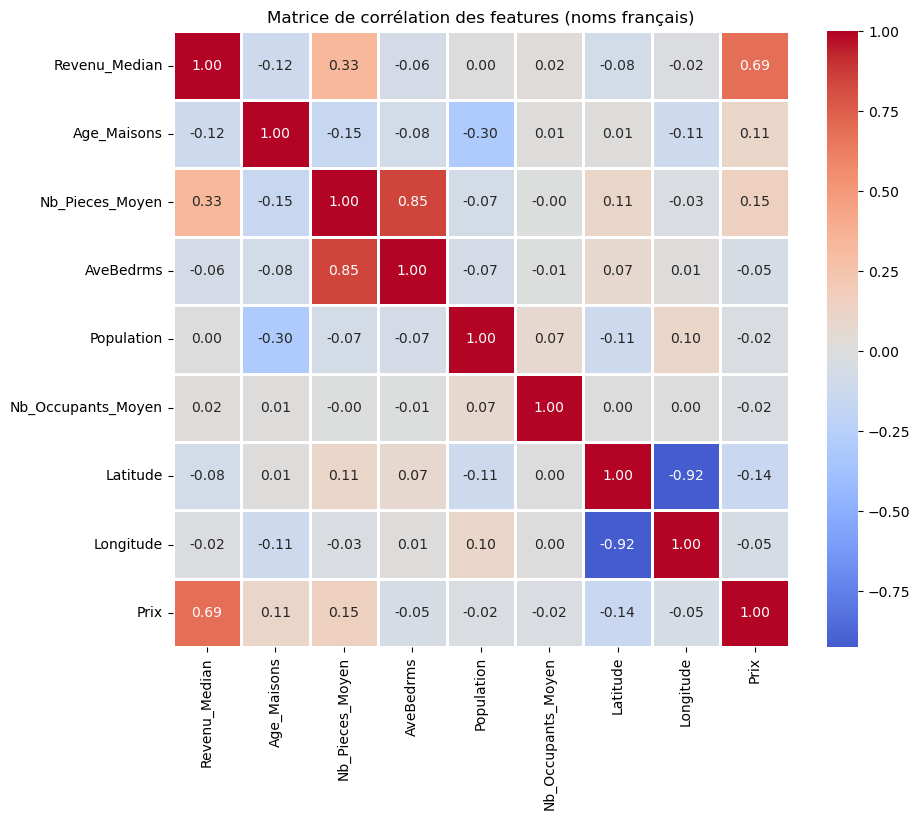

 Features les plus corrélées avec le prix:
Revenu_Median         0.688075
Nb_Pieces_Moyen       0.151948
Age_Maisons           0.105623
Nb_Occupants_Moyen   -0.023737
Population           -0.024650
Longitude            -0.045967
AveBedrms            -0.046701
Latitude             -0.144160
Name: Prix, dtype: float64


In [9]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('Matrice de corrélation des features (noms français)')
plt.show()

# Features les plus corrélées avec le prix
corr_with_price = corr['Prix'].drop('Prix').sort_values(ascending=False)
print(" Features les plus corrélées avec le prix:")
print(corr_with_price)

## 8. VISUALISATION 4: CARTE DES PRIX

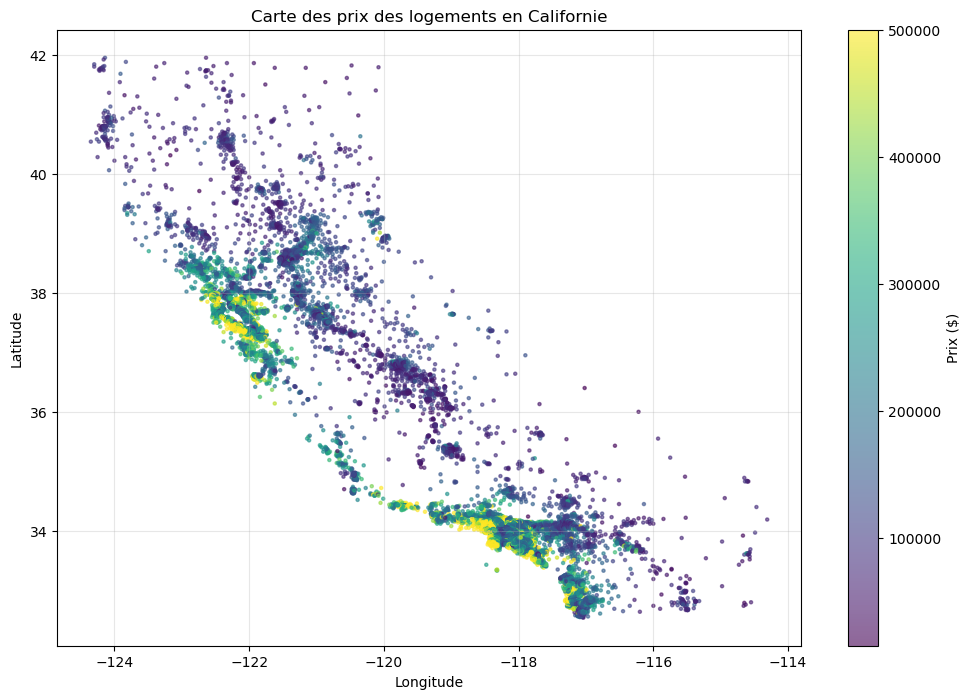

In [10]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['Longitude'], df['Latitude'], 
                      c=df['Prix'], cmap='viridis', 
                      s=5, alpha=0.6)
plt.colorbar(scatter, label='Prix ($)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Carte des prix des logements en Californie')
plt.grid(True, alpha=0.3)
plt.show()

## 9. PRÉPARATION DES DONNÉES

In [11]:
# Séparation features/target
X = df.drop('Prix', axis=1)  # Toutes les features SAUF le prix
y = df['Prix']                # La target (prix à prédire)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f" Train set: {X_train.shape[0]} échantillons")
print(f" Test set: {X_test.shape[0]} échantillons")

# Standardisation (pour modèles linéaires)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(" Données standardisées")

print("\n Features (noms français):")
print(X.columns.tolist())

 Train set: 16512 échantillons
 Test set: 4128 échantillons
 Données standardisées

 Features (noms français):
['Revenu_Median', 'Age_Maisons', 'Nb_Pieces_Moyen', 'AveBedrms', 'Population', 'Nb_Occupants_Moyen', 'Latitude', 'Longitude']


## 10. DÉFINITION DES MODÈLES

In [12]:
models = {
    'Régression Linéaire': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print(" Modèles à entraîner:")
for name in models.keys():
    print(f"   {name}")

 Modèles à entraîner:
   Régression Linéaire
   Ridge
   Random Forest
   Gradient Boosting


## 11. ENTRAÎNEMENT DES MODÈLES

In [13]:

results = {}

for name, model in models.items():
    print(f"\n Entraînement: {name}...")
    
    # Choix des données selon le modèle
    if name in ['Régression Linéaire', 'Ridge']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Métriques
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Validation croisée
    if name in ['Régression Linéaire', 'Ridge']:
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    else:
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    
    results[name] = {
        'R²': r2,
        'RMSE': rmse,
        'MAE': mae,
        'CV R²': cv_scores.mean()
    }
    
    print(f"  R²: {r2:.4f}")
    print(f"  RMSE: ${rmse:,.0f}")
    print(f"  MAE: ${mae:,.0f}")


 Entraînement: Régression Linéaire...
  R²: 0.5758
  RMSE: $74,558
  MAE: $53,320

 Entraînement: Ridge...
  R²: 0.5758
  RMSE: $74,556
  MAE: $53,319

 Entraînement: Random Forest...
  R²: 0.8038
  RMSE: $50,710
  MAE: $32,812

 Entraînement: Gradient Boosting...
  R²: 0.7756
  RMSE: $54,222
  MAE: $37,164


## 12. COMPARAISON DES MODÈLES

In [14]:
results_df = pd.DataFrame(results).T
print(" TABLEAU COMPARATIF DES MODÈLES:")
print("="*70)
print(results_df.round(4))
print("="*70)

# Meilleur modèle
best_model = results_df['R²'].idxmax()
best_r2 = results_df.loc[best_model, 'R²']
print(f"\n MEILLEUR MODÈLE: {best_model} avec R² = {best_r2:.4f}")

 TABLEAU COMPARATIF DES MODÈLES:
                         R²        RMSE         MAE   CV R²
Régression Linéaire  0.5758  74558.1383  53320.0130  0.6115
Ridge                0.5758  74555.6744  53319.3120  0.6115
Random Forest        0.8038  50710.3820  32811.6779  0.8043
Gradient Boosting    0.7756  54221.5202  37164.2569  0.7866

 MEILLEUR MODÈLE: Random Forest avec R² = 0.8038


## 13. VISUALISATION COMPARATIVE

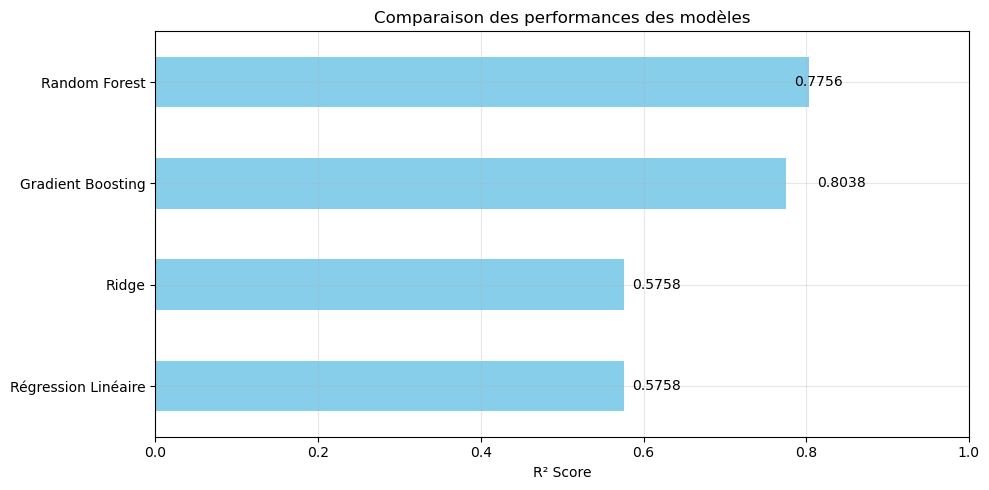

In [15]:
plt.figure(figsize=(10, 5))
results_df['R²'].sort_values().plot(kind='barh', color='skyblue')
plt.xlabel('R² Score')
plt.title('Comparaison des performances des modèles')
plt.xlim(0, 1)
for i, (name, row) in enumerate(results_df.iterrows()):
    plt.text(row['R²'] + 0.01, i, f'{row["R²"]:.4f}', va='center')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 14. ANALYSE DU MEILLEUR MODÈLE

In [16]:

print(f" Analyse détaillée du meilleur modèle: {best_model}")

# Récupération du meilleur modèle
if best_model in ['Régression Linéaire', 'Ridge']:
    final_model = models[best_model]
    final_model.fit(X_train_scaled, y_train)
    y_pred_final = final_model.predict(X_test_scaled)
else:
    final_model = models[best_model]
    final_model.fit(X_train, y_train)
    y_pred_final = final_model.predict(X_test)

# Métriques finales
final_mae = mean_absolute_error(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_r2 = r2_score(y_test, y_pred_final)
errors = y_test - y_pred_final

print(f"\n Performances finales:")
print(f"   R²: {final_r2:.4f}")
print(f"   RMSE: ${final_rmse:,.0f}")
print(f"   MAE: ${final_mae:,.0f}")
print(f"   Erreur relative: {(final_mae/y_test.mean())*100:.1f}%")

 Analyse détaillée du meilleur modèle: Random Forest

 Performances finales:
   R²: 0.8038
   RMSE: $50,710
   MAE: $32,812
   Erreur relative: 16.0%



## 15. VISUALISATIONS FINALES

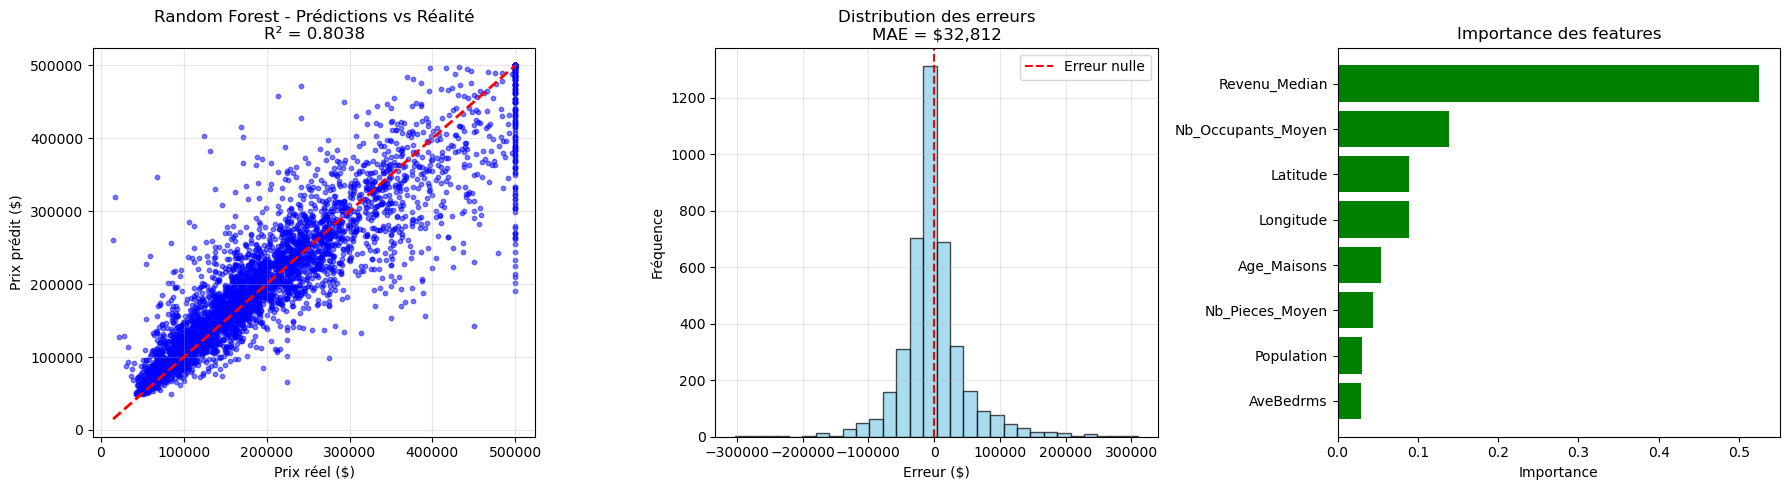

In [19]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphique 1: Prédictions vs Réalité
axes[0].scatter(y_test, y_pred_final, alpha=0.5, s=10, c='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Prix réel ($)')
axes[0].set_ylabel('Prix prédit ($)')
axes[0].set_title(f'{best_model} - Prédictions vs Réalité\nR² = {final_r2:.4f}')
axes[0].grid(True, alpha=0.3)

# Graphique 2: Distribution des erreurs
axes[1].hist(errors, bins=30, edgecolor='black', color='skyblue', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', label='Erreur nulle')
axes[1].set_xlabel('Erreur ($)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title(f'Distribution des erreurs\nMAE = ${final_mae:,.0f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Graphique 3: Importance des features 
if best_model in ['Random Forest', 'Gradient Boosting']:
    importances = final_model.feature_importances_
    indices = np.argsort(importances)[::-1][:8]
    features_fr = X.columns[indices][::-1]
    axes[2].barh(range(8), importances[indices][::-1], color='green')
    axes[2].set_yticks(range(8))
    axes[2].set_yticklabels(features_fr)
    axes[2].set_xlabel('Importance')
    axes[2].set_title('Importance des features')
else:
    axes[2].text(0.5, 0.5, 'Importance non disponible', 
                ha='center', va='center', transform=axes[2].transAxes)

plt.tight_layout()
plt.show()

## 16. FONCTION DE PRÉDICTION 

In [21]:

def predire_prix(Revenu_Median, Age_Maisons, Nb_Pieces_Moyen, Nb_Chambres_Moyen, 
                 Population, Nb_Occupants_Moyen, Latitude, Longitude):
    """
    Prédit le prix d'une maison en Californie
    Tous les paramètres en français !
    """
    donnees = pd.DataFrame([[Revenu_Median, Age_Maisons, Nb_Pieces_Moyen, Nb_Chambres_Moyen,
                             Population, Nb_Occupants_Moyen, Latitude, Longitude]],
                           columns=X.columns)
    
    if best_model in ['Régression Linéaire', 'Ridge']:
        donnees_scaled = scaler.transform(donnees)
        prix = final_model.predict(donnees_scaled)[0]
    else:
        prix = final_model.predict(donnees)[0]
    
    return prix

# Test de la fonction
print(" Test de prédiction avec des valeurs moyennes:")
prix_test = predire_prix(
    Revenu_Median=5.0,      # Revenu médian: $50,000
    Age_Maisons=20,         # Âge: 20 ans
    Nb_Pieces_Moyen=5.5,    # 5.5 pièces
    Nb_Chambres_Moyen=1.1,  # 1.1 chambres
    Population=1500,        # Population
    Nb_Occupants_Moyen=3.0, # 3 occupants
    Latitude=34.5,          # Latitude
    Longitude=-118.5        # Longitude
)

print(f" Prix prédit: ${prix_test:,.2f}")

 Test de prédiction avec des valeurs moyennes:
 Prix prédit: $238,233.02


## 17. RAPPORT FINAL

In [25]:

print("="*60)
print(" RAPPORT FINAL - PROJET EXAMEN")
print("="*60)
print(f"""
 SUJET: Prédiction des prix de logements (Régression)
 DATASET: California Housing ({df.shape[0]} échantillons)
 FEATURES (noms français): {', '.join(X.columns)}

 ANALYSE EXPLORATOIRE:
   • Prix moyen: ${df['Prix'].mean():,.0f}
   • Corrélation la plus forte: Revenu_Median ({df['Revenu_Median'].corr(df['Prix']/100000):.3f})
   • Valeurs manquantes: {df.isnull().sum().sum()}

 MODÈLES TESTÉS:
   • Régression Linéaire
   • Ridge
   • Random Forest
   • Gradient Boosting

 RÉSULTATS:
   • Meilleur modèle: {best_model}
   • R² Score: {final_r2:.4f}
   • RMSE: ${final_rmse:,.0f}
   • MAE: ${final_mae:,.0f}
   • Erreur relative: {(final_mae/y_test.mean())*100:.1f}%

 CONCLUSION:
   Le modèle {best_model} explique {final_r2*100:.1f}% de la variance des prix
   avec une erreur moyenne de ${final_mae:,.0f}.
""")
print("="*60)
print("\n EXAMEN PRÊT! Bonne chance! ")

 RAPPORT FINAL - PROJET EXAMEN

 SUJET: Prédiction des prix de logements (Régression)
 DATASET: California Housing (20640 échantillons)
 FEATURES (noms français): Revenu_Median, Age_Maisons, Nb_Pieces_Moyen, AveBedrms, Population, Nb_Occupants_Moyen, Latitude, Longitude

 ANALYSE EXPLORATOIRE:
   • Prix moyen: $206,856
   • Corrélation la plus forte: Revenu_Median (0.688)
   • Valeurs manquantes: 0

 MODÈLES TESTÉS:
   • Régression Linéaire
   • Ridge
   • Random Forest
   • Gradient Boosting

 RÉSULTATS:
   • Meilleur modèle: Random Forest
   • R² Score: 0.8038
   • RMSE: $50,710
   • MAE: $32,812
   • Erreur relative: 16.0%

 CONCLUSION:
   Le modèle Random Forest explique 80.4% de la variance des prix
   avec une erreur moyenne de $32,812.


 EXAMEN PRÊT! Bonne chance! 
